# pybvh-ml Feature Gallery

Every pybvh-ml-specific capability, one picture and one call each — the concepts a data-plumbing library is usually forced to explain in prose: tensor layouts, centering hazards, skeleton graphs, reproducible augmentation, sequence sampling, and batch masking.

Skeleton renders use pybvh's `bvhplot`; for the plain per-function augmentation before/afters (mirror, rotation, noise on a single skeleton), see [pybvh's own gallery](https://victors-67.github.io/pybvh/gallery/) — this page draws only what pybvh can't.

In [1]:
import warnings

import matplotlib
try:
    get_ipython  # defined inside an IPython / Jupyter kernel
except NameError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from pybvh import read_bvh_file, bvhplot
import gallery_plots as gp

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "gallery" else Path.cwd()
BVH_DIR = REPO_ROOT / "bvh_data"

# Capture load-time warnings (world-up inference notes) and print only their
# messages, so the committed outputs stay portable.
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    bvh = read_bvh_file(BVH_DIR / "bvh_test1.bvh")
for w in caught:
    print(f"[{w.category.__name__}] {w.message}")

root_pos, jd6 = bvh.to_6d()
_, quats = bvh.to_quat()
print(f"hero clip: {bvh.joint_count} joints, {bvh.frame_count} frames, "
      f"world_up {bvh.world_up}")

hero clip: 24 joints, 75 frames, world_up +z


## 1 · Tensor layouts & packing

**`pack_to_ctv` / `pack_to_tvc` / `pack_to_flat`** — one clip, three model-ready layouts. The root is vertex 0; with 6D joint data (C = 6) its channels `3:6` are zero padding, and `describe_features` maps every flat column back to its feature block.

CTV (6, 75, 25)   TVC (75, 25, 6)   flat (75, 147)


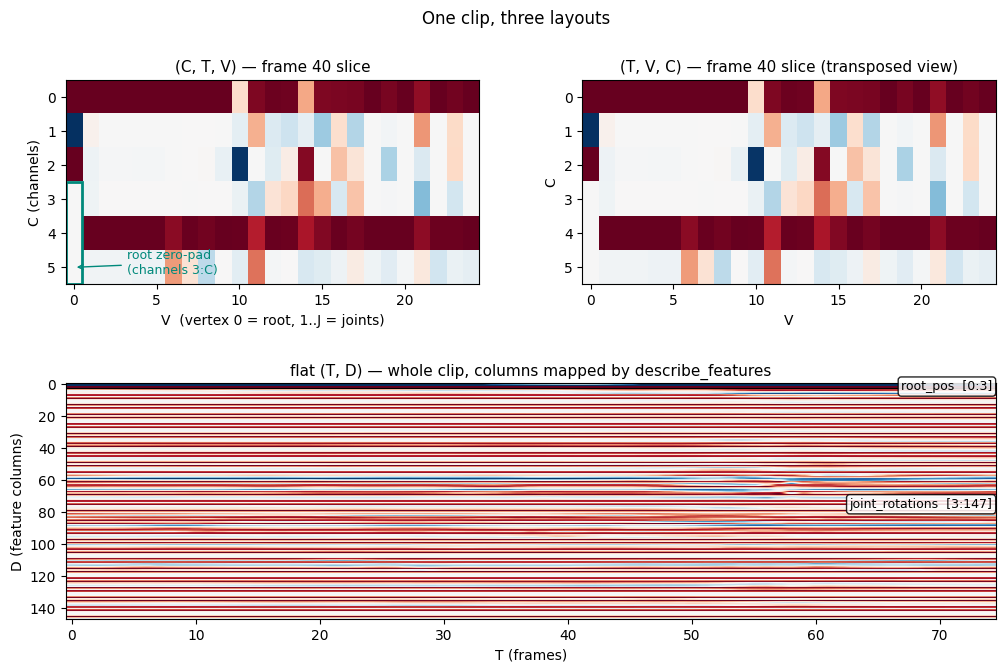

In [2]:
from pybvh_ml import pack_to_ctv, pack_to_tvc, pack_to_flat, describe_features

ctv = pack_to_ctv(root_pos, jd6, center_root=False)
tvc = pack_to_tvc(root_pos, jd6, center_root=False)
flat = pack_to_flat(root_pos, jd6, center_root=False)
desc = describe_features(bvh.joint_count, representation="6d")
print(f"CTV {ctv.shape}   TVC {tvc.shape}   flat {flat.shape}")

fig = gp.fig_layouts(ctv, tvc, flat,
                     {"root_pos": desc["root_pos"],
                      "joint_rotations": desc["joint_rotations"]},
                     frame=40)
plt.show()

**`center_root`** — the packers subtract the first frame's root position (on by default). Center the *whole clip* once and windows keep their place on the global trajectory; pack each *window* with `center_root=True` and every window is re-based to its own origin — the trajectory is destroyed. Top view of the hero clip's root path.

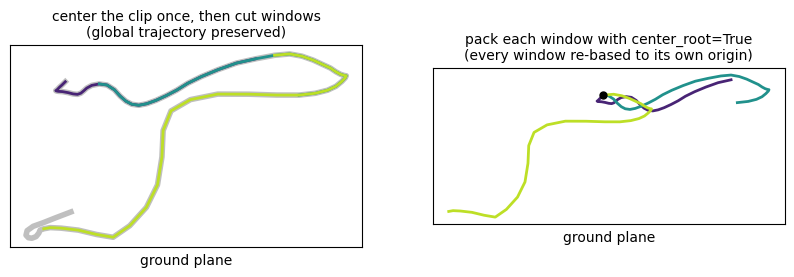

In [3]:
fig = gp.fig_center_hazard(root_pos, up_index=2, window=32, stride=16)
plt.show()

## 2 · Skeleton graph metadata

**`get_edge_list` / `get_lr_pairs`** — the topology GCN adjacency matrices are built from: parent/child edges, plus the left/right joint pairs that `mirror` swaps (detected from joint names via pybvh's L/R heuristics).

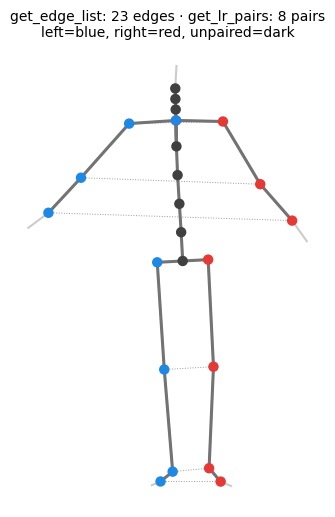

In [4]:
from pybvh_ml import get_edge_list, get_lr_pairs, get_body_partitions

edges = get_edge_list(bvh)
lr_pairs = get_lr_pairs(bvh)
fig = gp.fig_graph(bvh, edges, lr_pairs)
plt.show()

**`get_body_partitions`** — named body-part groups as joint index lists, for part-based pooling or attention masks.

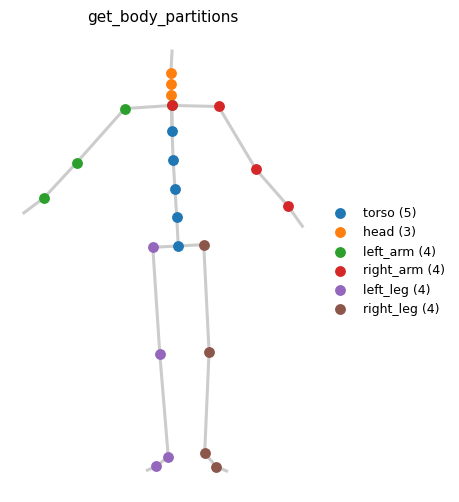

In [5]:
partitions = get_body_partitions(bvh)
fig = gp.fig_partitions(bvh, partitions)
plt.show()

## 3 · Array-level augmentation

**`speed_perturbation_arrays` / `dropout_arrays`** — the two temporal augmentations, invisible in a skeleton still: speed perturbation resamples the time axis (SLERP between frames), dropout drops random frames and re-interpolates across the gaps. One lively joint coordinate over time.

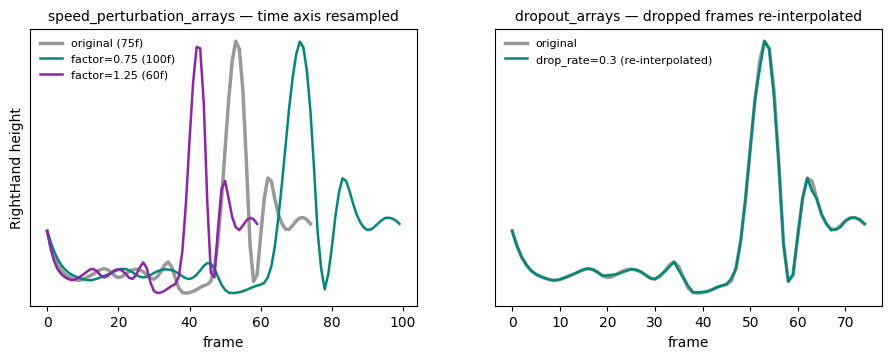

In [6]:
from pybvh_ml import speed_perturbation_arrays, dropout_arrays

coords = bvh.node_positions()
joint_nodes = [bvh.index(n, space="node") for n in bvh.joint_names]
up = 2                                      # +z up
lively = int(np.argmax(coords[:, joint_nodes, up].std(axis=0)))
node = joint_nodes[lively]


def track(rp, q):
    rebuilt = bvh.from_quat(rp, q)
    return rebuilt.node_positions()[:, node, up]


rng = np.random.default_rng(7)
slow = speed_perturbation_arrays(root_pos=root_pos, joint_data=quats,
                                 factor=0.75, representation="quat")
fast = speed_perturbation_arrays(root_pos=root_pos, joint_data=quats,
                                 factor=1.25, representation="quat")
drop = dropout_arrays(root_pos=root_pos, joint_data=quats,
                      drop_rate=0.3, representation="quat", rng=rng)

fig = gp.fig_speed_dropout(f"{bvh.joint_names[lively]} height",
                           track(root_pos, quats), track(*slow),
                           track(*fast), track(*drop))
plt.show()

**`AugmentationPipeline.standard`** — rotate + mirror + noise + speed wired from a `skeleton_info` dict, with per-step probabilities and per-sample random parameters. Three independent draws from the same pipeline.

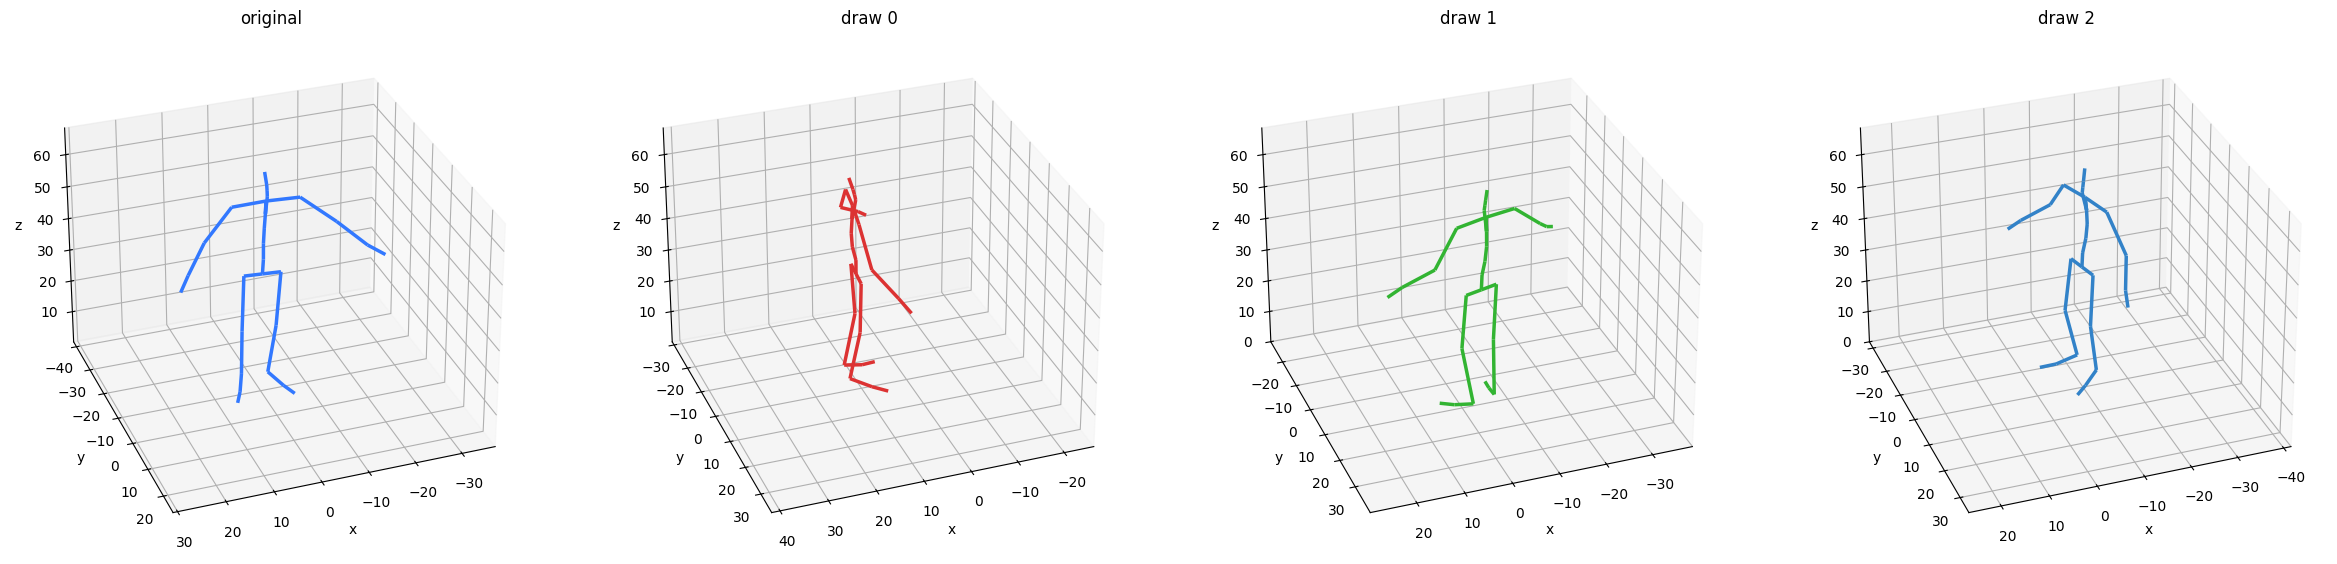

In [7]:
from pybvh_ml import AugmentationPipeline, get_skeleton_info

skel = get_skeleton_info(bvh)
pipeline = AugmentationPipeline.standard(skel, representation="quat",
                                         up_axis=bvh.world_up)
draws = []
for i in range(3):
    rp_i, q_i = pipeline(root_pos=root_pos, joint_data=quats,
                         rng=np.random.default_rng(i))
    draws.append(bvh.from_quat(rp_i, q_i))

fig, axes = bvhplot.frame([bvh, *draws], frame=0,
                          labels=["original", "draw 0", "draw 1", "draw 2"],
                          camera=(70, 30))
plt.show()

## 4 · Reproducibility: seed × epoch × index

**`set_epoch`** — with a `seed`, the tuple `(seed, epoch, idx)` feeds a `SeedSequence`: two runs with the same seed draw bit-identical augmentations (regardless of `num_workers` or shuffle order), while each epoch still sees a fresh draw. Two independently constructed datasets, three epochs each.

epoch 0: run A == run B → True
epoch 1: run A == run B → True
epoch 2: run A == run B → True


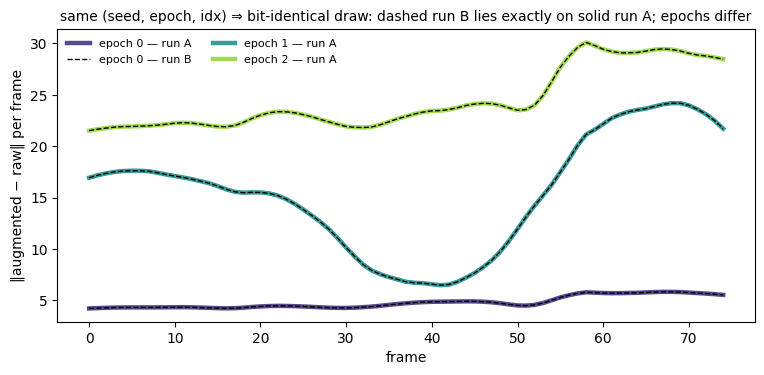

In [8]:
from pybvh_ml.torch import MotionDataset

clip = {"root_pos": root_pos, "joint_data": jd6}
# speed perturbation changes the frame count, so disable it here to keep the
# per-frame deviation against the raw clip well-defined
pipeline6 = AugmentationPipeline.standard(skel, representation="6d",
                                          up_axis=bvh.world_up,
                                          speed_factor_range=None)
base = MotionDataset([clip])[0]["data"].numpy()

curves = {}
for run in ("A", "B"):
    ds = MotionDataset([clip], augmentation=pipeline6, seed=42)
    for epoch in range(3):
        ds.set_epoch(epoch)
        aug = ds[0]["data"].numpy()
        curves[(run, epoch)] = np.linalg.norm(aug - base, axis=1)

for epoch in range(3):
    same = np.array_equal(curves[("A", epoch)], curves[("B", epoch)])
    print(f"epoch {epoch}: run A == run B → {same}")
fig = gp.fig_epoch_determinism(curves)
plt.show()

## 5 · Sequence tools

**`sliding_window` / `standardize_length`** — cut overlapping windows, or pad/crop to an exact length (models want fixed shapes; clips don't have them).

windows (3, 32, 147)   padded (100, 147)   cropped (50, 147)


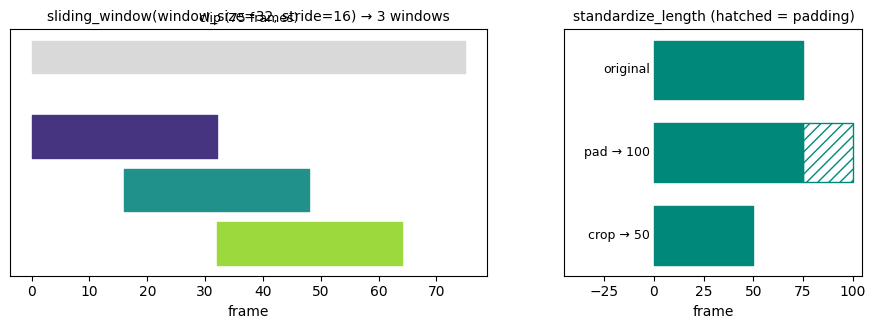

In [9]:
from pybvh_ml import sliding_window, standardize_length

windows = sliding_window(flat, window_size=32, stride=16)
padded = standardize_length(flat, target_length=100, method="pad")
cropped = standardize_length(flat, target_length=50, method="crop")
print(f"windows {windows.shape}   padded {padded.shape}   "
      f"cropped {cropped.shape}")

fig = gp.fig_windows(bvh.frame_count, window=32, stride=16,
                     pad_to=100, crop_to=50)
plt.show()

**`uniform_temporal_sample`** — PySKL-style sampling for skeleton-based recognition: split the clip into `clip_length` equal segments, pick one frame per segment. Train mode draws a random offset per segment; test mode is deterministic.

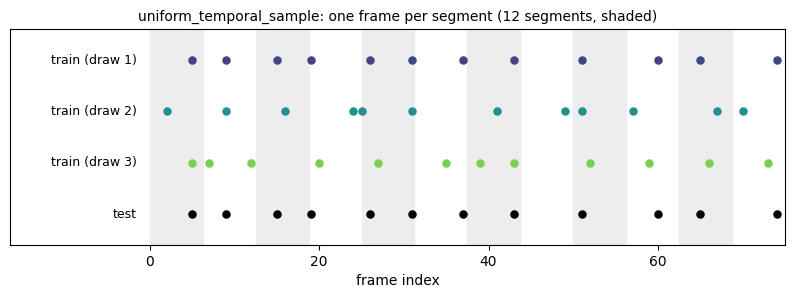

In [10]:
from pybvh_ml import uniform_temporal_sample

F, L = bvh.frame_count, 12
train_draws = [uniform_temporal_sample(F, L, mode="train",
                                       rng=np.random.default_rng(i))
               for i in range(3)]
test_draw = uniform_temporal_sample(F, L, mode="test")
fig = gp.fig_temporal_sample(F, L, train_draws, test_draw)
plt.show()

## 6 · Preprocessing

**`compute_normalization_stats` / `normalize_array`** — per-channel z-score over the flat `[root_pos, joint_data]` layout (the `Mean.npy` / `Std.npy` convention). Channels whose std is ~0 are guarded to 1 and flagged in the `constant_channels` mask.

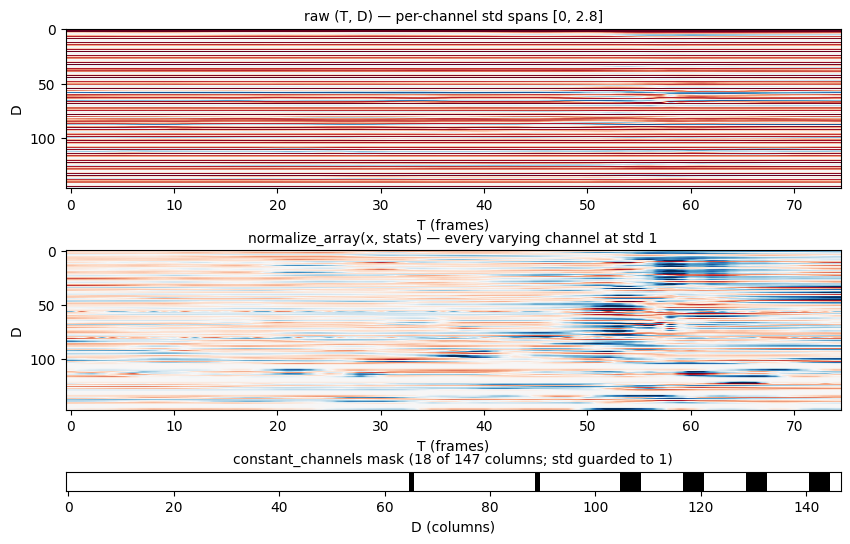

In [11]:
from pybvh_ml import compute_normalization_stats, normalize_array

stats = compute_normalization_stats([bvh], representation="6d")
flat_norm = normalize_array(flat, stats)
fig = gp.fig_normalization(flat, flat_norm, stats["constant_channels"])
plt.show()

**`harmonize=True`** — `preprocess_directory`'s answer to heterogeneous corpora, via `pybvh.harmonize`: three fixture clips with mixed up-axis conventions, reoriented to one shared convention. Pure reorientation — each actor's bone lengths are untouched (`retarget=True` opts into unifying those too).

[UserWarning] Rest pose suggests world up is '+y' but the first animation frame's head-hips direction is closer to '+z'. Using '+z' from the animation data. If this is wrong for your file, set it explicitly via `bvh.world_up = '<axis>'`.
before: ['+z', '+y', '+z'] → after: ['+z', '+z', '+z']


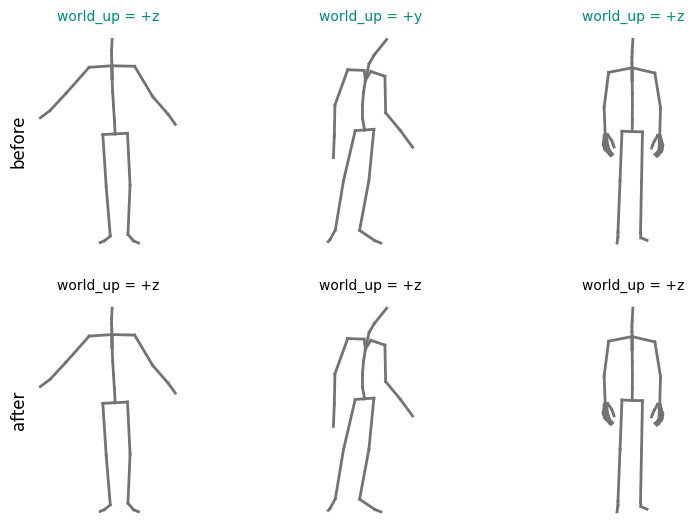

In [12]:
from pybvh import harmonize

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    mixed = [read_bvh_file(BVH_DIR / f"{name}.bvh")
             for name in ("bvh_test1", "bvh_test2", "bvh_test3")]
    unified = harmonize(mixed, target_world_up="+z")
for w in caught:
    print(f"[{w.category.__name__}] {w.message}")

print("before:", [b.world_up for b in mixed],
      "→ after:", [b.world_up for b in unified])
fig = gp.fig_harmonize(mixed, unified)
plt.show()

## 7 · PyTorch batching

**`collate_motion_batch`** — variable-length clips stacked into one padded tensor plus a validity mask and true lengths. Four slices of the hero clip, batched.

{'data': (4, 75, 147), 'lengths': (4,), 'mask': (4, 75)}


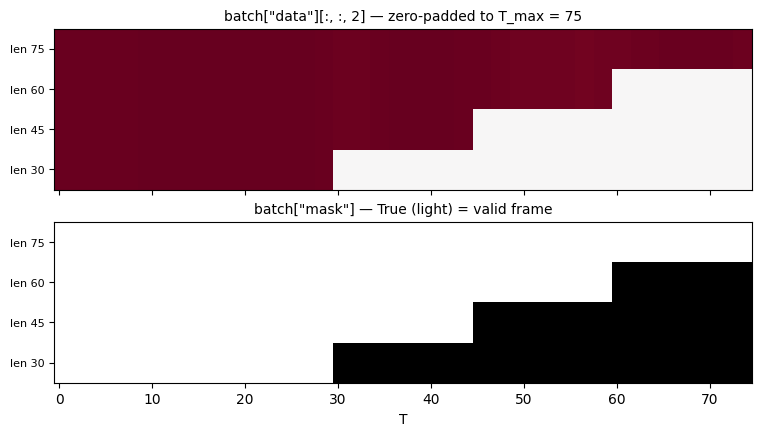

In [13]:
from pybvh_ml.torch import collate_motion_batch

lengths = [75, 60, 45, 30]
clips = [{"root_pos": root_pos[:n], "joint_data": jd6[:n]} for n in lengths]
ds = MotionDataset(clips)
batch = collate_motion_batch([ds[i] for i in range(len(ds))])
print({k: tuple(v.shape) for k, v in batch.items()})

fig = gp.fig_collate_mask(batch)
plt.show()

## Takeaways

Every figure above is one pybvh-ml call on real fixture data — no model, no training loop. The [User Guide](https://victors-67.github.io/pybvh-ml/guide/tensor-layouts/) walks the same ground in prose, the [API reference](https://victors-67.github.io/pybvh-ml/api/) has every signature, and the [tutorials](https://victors-67.github.io/pybvh-ml/tutorials/) chain these pieces into a trained classifier.